In [1]:
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("/var/threat-intel/datasets")
MODELS_DIR = Path("/home/ubuntu/threat-intel-platform/ml/models")
REPORTS_DIR = Path("/home/ubuntu/threat-intel-platform/ml/reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Load all CSVs (same approach as 7B)
csv_files = sorted(DATA_DIR.rglob("*.csv"))
dfs = [pd.read_csv(f, low_memory=False) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)
del dfs

# Apply the 7B fixes
df.columns = df.columns.str.strip()

# Load feature config from 7B
with open(MODELS_DIR / 'feature_config.json') as f:
    config = json.load(f)

# Apply production label mapping
df['production_label'] = df['Label'].map(config['label_map'])

# Drop rows with unmapped labels (shouldn't be any)
print(f"Rows before label mapping: {len(df):,}")
df = df.dropna(subset=['production_label'])
print(f"Rows after label mapping: {len(df):,}")

# Drop the leaky and useless features identified in 7B
drop_cols = [c for c in config['drop_features'] if c in df.columns]
print(f"Dropping {len(drop_cols)} features identified as leaky or constant")

# Build the feature matrix
y = df['production_label'].values
feature_cols = [c for c in df.columns if c not in drop_cols + ['Label', 'production_label']]
X = df[feature_cols].copy()

print(f"\nFeature count: {len(feature_cols)}")
print(f"Sample count: {len(X):,}")
print(f"\nClass distribution:")
print(pd.Series(y).value_counts())

Rows before label mapping: 2,830,743
Rows after label mapping: 2,830,743
Dropping 13 features identified as leaky or constant

Feature count: 65
Sample count: 2,830,743

Class distribution:
BENIGN          2273097
DoS              380688
PortScan         158930
Bruteforce        13835
WebAttack          2180
Botnet             1966
Infiltration         47
Name: count, dtype: int64


In [3]:
# Replace Inf with NaN, then fill NaN with column medians.
# Medians are robust to outliers (which DoS traffic has plenty of).
X = X.replace([np.inf, -np.inf], np.nan)
nan_count = X.isna().sum().sum()
print(f"Total NaN cells: {nan_count:,}")

# Fill with column medians
X = X.fillna(X.median())

# Sanity check
assert X.isna().sum().sum() == 0, "NaN remaining"
assert not np.isinf(X.values).any(), "Inf remaining"
print("Data clean")

Total NaN cells: 5,734
Data clean


In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

# Stratified subsample to 500k for tractable training
# Preserves class proportions
SAMPLE_SIZE = min(500_000, len(X))
if len(X) > SAMPLE_SIZE:
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
    sample_idx, _ = next(splitter.split(X, y))
    X_sampled = X.iloc[sample_idx].reset_index(drop=True)
    y_sampled = y[sample_idx]
else:
    X_sampled = X.reset_index(drop=True)
    y_sampled = y

print(f"Sampled to {len(X_sampled):,} flows")
print(f"\nSampled class distribution:")
print(pd.Series(y_sampled).value_counts())

# Free memory
del X, y, df
import gc; gc.collect()

Sampled to 500,000 flows

Sampled class distribution:
BENIGN          401502
DoS              67242
PortScan         28072
Bruteforce        2444
WebAttack          385
Botnet             347
Infiltration         8
Name: count, dtype: int64


9

In [5]:
# Label encoding for XGBoost (needs integer classes)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_sampled)
class_names = label_encoder.classes_
print(f"Classes: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

# Hold out 20% for final evaluation, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_sampled, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=RANDOM_STATE,
)
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")

# Scale features. Tree models don't strictly need scaling, but it makes
# the saved pipeline robust to future linear-model additions and helps
# isolation forest behave consistently.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Classes: {'BENIGN': 0, 'Botnet': 1, 'Bruteforce': 2, 'DoS': 3, 'Infiltration': 4, 'PortScan': 5, 'WebAttack': 6}
Train: 400,000, Test: 100,000


In [6]:
print("=" * 60)
print("Training Random Forest baseline with 5-fold CV")
print("=" * 60)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,              # Limit depth to avoid memorizing dataset quirks
    min_samples_leaf=5,        # Don't split on tiny groups
    class_weight='balanced',   # Compensate for class imbalance
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

# 5-fold cross-validation on TRAIN set only
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {'precision_macro': [], 'recall_macro': [], 'f1_macro': []}
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
    rf.fit(X_train_scaled[tr_idx], y_train[tr_idx])
    preds = rf.predict(X_train_scaled[val_idx])
    p, r, f, _ = precision_recall_fscore_support(
        y_train[val_idx], preds, average='macro', zero_division=0
    )
    cv_scores['precision_macro'].append(p)
    cv_scores['recall_macro'].append(r)
    cv_scores['f1_macro'].append(f)
    print(f"  Fold {fold+1}: precision={p:.4f}, recall={r:.4f}, f1={f:.4f}")

print(f"\nRandom Forest CV (mean ± std):")
for metric, scores in cv_scores.items():
    print(f"  {metric}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Final fit on full train set for test evaluation
rf.fit(X_train_scaled, y_train)
rf_test_preds = rf.predict(X_test_scaled)
print("\nRandom Forest TEST set classification report:")
print(classification_report(y_test, rf_test_preds, target_names=class_names, zero_division=0))

Training Random Forest baseline with 5-fold CV
  Fold 1: precision=0.7210, recall=0.8355, f1=0.7295
  Fold 2: precision=0.7330, recall=0.8435, f1=0.7478
  Fold 3: precision=0.7295, recall=0.8348, f1=0.7327
  Fold 4: precision=0.7449, recall=0.8380, f1=0.7612
  Fold 5: precision=0.7258, recall=0.8337, f1=0.7375

Random Forest CV (mean ± std):
  precision_macro: 0.7308 ± 0.0081
  recall_macro: 0.8371 ± 0.0035
  f1_macro: 0.7417 ± 0.0115

Random Forest TEST set classification report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      1.00     80300
      Botnet       0.12      0.97      0.22        69
  Bruteforce       1.00      0.99      0.99       489
         DoS       0.99      1.00      1.00     13449
Infiltration       1.00      0.50      0.67         2
    PortScan       0.99      1.00      1.00      5614
   WebAttack       0.99      0.92      0.95        77

    accuracy                           0.99    100000
   macro avg       0.87   

In [7]:
print("=" * 60)
print("Training XGBoost (headline model) with 5-fold CV")
print("=" * 60)

# XGBoost hyperparameters chosen for:
# - max_depth=8: deep enough to learn behavior, shallow enough to not memorize
# - learning_rate=0.1: standard
# - n_estimators=200: more boosters compensate for shallow depth
# - subsample=0.8: prevent overfitting to specific samples
# - tree_method='hist': much faster than default 'exact'
xgb_params = dict(
    max_depth=8,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    eval_metric='mlogloss',
)

cv_scores_xgb = {'precision_macro': [], 'recall_macro': [], 'f1_macro': []}
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_train_scaled[tr_idx], y_train[tr_idx])
    preds = model.predict(X_train_scaled[val_idx])
    p, r, f, _ = precision_recall_fscore_support(
        y_train[val_idx], preds, average='macro', zero_division=0
    )
    cv_scores_xgb['precision_macro'].append(p)
    cv_scores_xgb['recall_macro'].append(r)
    cv_scores_xgb['f1_macro'].append(f)
    print(f"  Fold {fold+1}: precision={p:.4f}, recall={r:.4f}, f1={f:.4f}")

print(f"\nXGBoost CV (mean ± std):")
for metric, scores in cv_scores_xgb.items():
    print(f"  {metric}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Final fit on full train set
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_train_scaled, y_train)
xgb_test_preds = xgb_model.predict(X_test_scaled)
xgb_test_proba = xgb_model.predict_proba(X_test_scaled)

print("\nXGBoost TEST set classification report:")
print(classification_report(y_test, xgb_test_preds, target_names=class_names, zero_division=0))

Training XGBoost (headline model) with 5-fold CV
  Fold 1: precision=0.8292, recall=0.8074, f1=0.8172
  Fold 2: precision=0.8341, recall=0.8237, f1=0.8288
  Fold 3: precision=0.8352, recall=0.8266, f1=0.8308
  Fold 4: precision=0.8326, recall=0.8132, f1=0.8223
  Fold 5: precision=0.8291, recall=0.7998, f1=0.8126

XGBoost CV (mean ± std):
  precision_macro: 0.8320 ± 0.0025
  recall_macro: 0.8141 ± 0.0100
  f1_macro: 0.8223 ± 0.0069

XGBoost TEST set classification report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     80300
      Botnet       0.86      0.71      0.78        69
  Bruteforce       1.00      0.99      0.99       489
         DoS       1.00      1.00      1.00     13449
Infiltration       0.00      0.00      0.00         2
    PortScan       0.99      1.00      1.00      5614
   WebAttack       0.99      0.95      0.97        77

    accuracy                           1.00    100000
   macro avg       0.83      0.81   

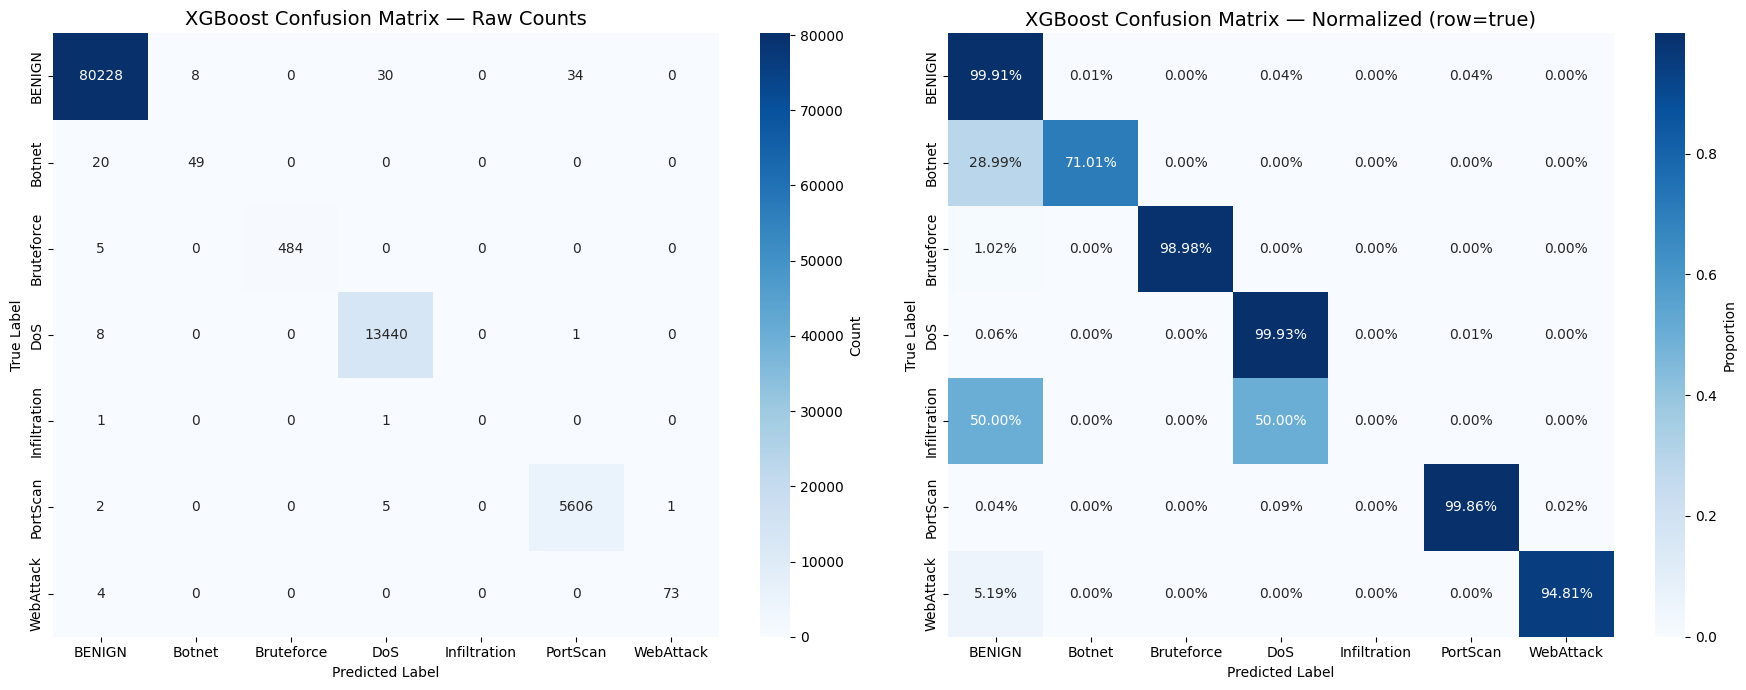


Saved: /home/ubuntu/threat-intel-platform/ml/reports/confusion_matrix_xgboost.png


In [8]:
cm = confusion_matrix(y_test, xgb_test_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[0], cbar_kws={'label': 'Count'},
)
axes[0].set_title('XGBoost Confusion Matrix — Raw Counts', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized (per-row, shows recall per class on diagonal)
sns.heatmap(
    cm_normalized, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[1], cbar_kws={'label': 'Proportion'},
)
axes[1].set_title('XGBoost Confusion Matrix — Normalized (row=true)', fontsize=14)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'confusion_matrix_xgboost.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nSaved: {REPORTS_DIR / 'confusion_matrix_xgboost.png'}")

Top 20 features by importance:
                    feature  importance
      Bwd Packet Length Std    0.185073
     Bwd Packet Length Mean    0.145372
      Bwd Packet Length Min    0.058728
          Packet Length Std    0.058421
          Max Packet Length    0.050008
        Average Packet Size    0.049523
             PSH Flag Count    0.038951
     Total Backward Packets    0.037909
        Fwd Header Length.1    0.032990
          Bwd Header Length    0.032879
              Bwd Packets/s    0.032361
Total Length of Fwd Packets    0.025099
          Fwd Header Length    0.023029
     Packet Length Variance    0.022466
         Packet Length Mean    0.018213
          Subflow Bwd Bytes    0.015044
Total Length of Bwd Packets    0.013587
          Subflow Fwd Bytes    0.013436
             FIN Flag Count    0.012953
             SYN Flag Count    0.011086


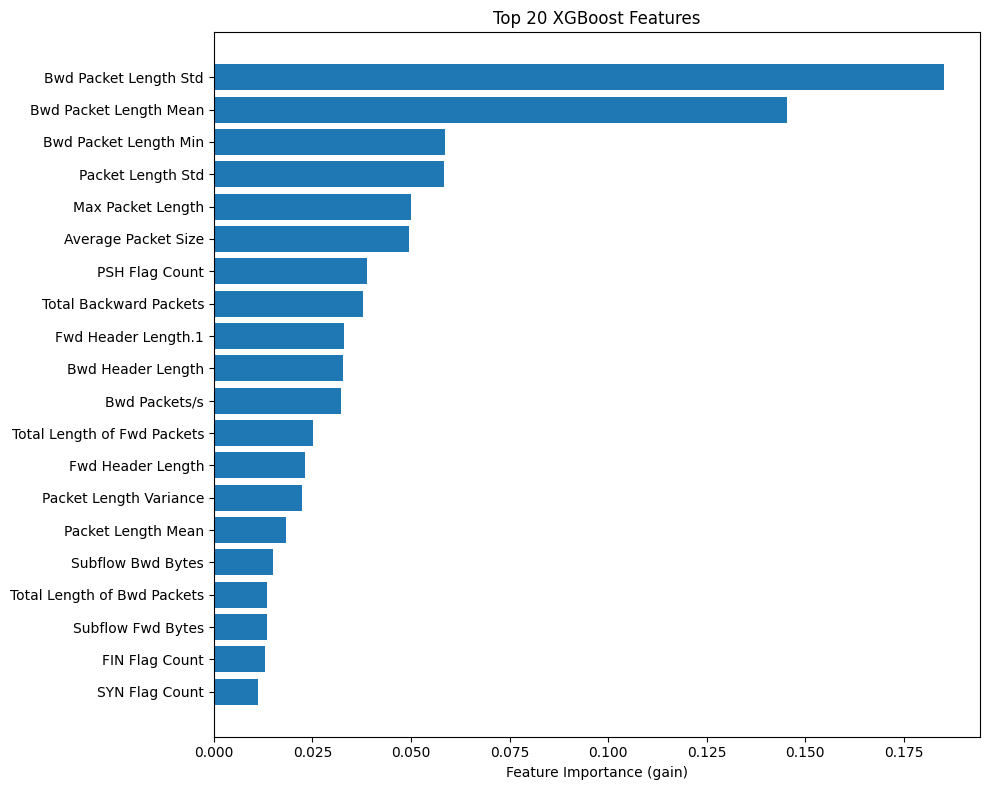


Saved: /home/ubuntu/threat-intel-platform/ml/reports/feature_importance_xgboost.png


In [9]:
# Top features by gain importance
importance = xgb_model.feature_importances_
feat_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': importance,
}).sort_values('importance', ascending=False)

print("Top 20 features by importance:")
print(feat_importance.head(20).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top20 = feat_importance.head(20)
ax.barh(range(len(top20)), top20['importance'].values[::-1])
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'].values[::-1])
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 20 XGBoost Features')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'feature_importance_xgboost.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nSaved: {REPORTS_DIR / 'feature_importance_xgboost.png'}")

In [10]:
print("=" * 60)
print("Training Isolation Forest (secondary anomaly channel)")
print("=" * 60)

# Train ONLY on benign — Isolation Forest learns "what normal looks like"
# and flags anything that deviates as anomalous, regardless of label.
benign_idx = (label_encoder.inverse_transform(y_train) == 'BENIGN')
X_train_benign = X_train_scaled[benign_idx]
print(f"Training on {len(X_train_benign):,} BENIGN flows")

# contamination=0.05 means we expect ~5% of unseen data to be anomalous.
# This sets the decision threshold.
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
iso_forest.fit(X_train_benign)

# Evaluate on test set
# Isolation Forest output: -1 = anomaly, 1 = normal
iso_preds = iso_forest.predict(X_test_scaled)
iso_anomaly = (iso_preds == -1).astype(int)

# True attack vs benign (binary)
y_test_binary = (label_encoder.inverse_transform(y_test) != 'BENIGN').astype(int)

# How well does anomaly score correlate with attack label?
from sklearn.metrics import precision_score, recall_score
iso_precision = precision_score(y_test_binary, iso_anomaly, zero_division=0)
iso_recall = recall_score(y_test_binary, iso_anomaly, zero_division=0)
print(f"\nIsolation Forest (binary: anomaly vs normal):")
print(f"  Precision: {iso_precision:.4f}")
print(f"  Recall: {iso_recall:.4f}")
print(f"\nNote: IF is the SECONDARY channel for novel anomalies.")
print(f"Lower precision is expected — XGBoost is the primary detector.")

Training Isolation Forest (secondary anomaly channel)
Training on 321,202 BENIGN flows

Isolation Forest (binary: anomaly vs normal):
  Precision: 0.5996
  Recall: 0.3081

Note: IF is the SECONDARY channel for novel anomalies.
Lower precision is expected — XGBoost is the primary detector.


In [11]:
print("=" * 60)
print("Saving model bundle")
print("=" * 60)

# Save XGBoost model
joblib.dump(xgb_model, MODELS_DIR / 'xgboost_classifier.pkl')

# Save Isolation Forest
joblib.dump(iso_forest, MODELS_DIR / 'isolation_forest.pkl')

# Save scaler — production must use the exact same scaling
joblib.dump(scaler, MODELS_DIR / 'feature_scaler.pkl')

# Save label encoder — to map back from integer to class name
joblib.dump(label_encoder, MODELS_DIR / 'label_encoder.pkl')

# Save the canonical feature order and metadata as JSON
# (Detection service will need this to align live features with training features)
model_metadata = {
    'feature_order': feature_cols,
    'class_names': class_names.tolist(),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'random_state': RANDOM_STATE,
    'xgb_params': xgb_params,
    'iso_forest_contamination': 0.05,
    'cv_results': {
        'random_forest': {k: [float(x) for x in v] for k, v in cv_scores.items()},
        'xgboost': {k: [float(x) for x in v] for k, v in cv_scores_xgb.items()},
    },
}

with open(MODELS_DIR / 'model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(f"Saved artifacts to {MODELS_DIR}/")
for f in sorted(MODELS_DIR.glob('*')):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"  {f.name} ({size_mb:.2f} MB)")

Saving model bundle
Saved artifacts to /home/ubuntu/threat-intel-platform/ml/models/
  feature_config.json (0.00 MB)
  feature_scaler.pkl (0.00 MB)
  isolation_forest.pkl (0.68 MB)
  label_encoder.pkl (0.00 MB)
  model_metadata.json (0.00 MB)
  xgboost_classifier.pkl (3.32 MB)


In [12]:
print("=" * 70)
print("FINAL EVALUATION REPORT — XGBoost on held-out test set")
print("=" * 70)

# Macro-averaged metrics
test_precision_macro = precision_recall_fscore_support(
    y_test, xgb_test_preds, average='macro', zero_division=0
)[0]
test_recall_macro = precision_recall_fscore_support(
    y_test, xgb_test_preds, average='macro', zero_division=0
)[1]
test_f1_macro = precision_recall_fscore_support(
    y_test, xgb_test_preds, average='macro', zero_division=0
)[2]

# Weighted (accounts for class imbalance)
test_precision_weighted = precision_recall_fscore_support(
    y_test, xgb_test_preds, average='weighted', zero_division=0
)[0]

print(f"\nTest set size: {len(y_test):,} flows")
print(f"\nHEADLINE METRICS:")
print(f"  Macro-averaged precision: {test_precision_macro:.4f}")
print(f"  Macro-averaged recall:    {test_recall_macro:.4f}")
print(f"  Macro-averaged F1:        {test_f1_macro:.4f}")
print(f"  Weighted precision:       {test_precision_weighted:.4f}")
print(f"  Accuracy (less useful):   {accuracy_score(y_test, xgb_test_preds):.4f}")

print(f"\nPER-CLASS PRECISION (the honest breakdown):")
per_class = precision_recall_fscore_support(
    y_test, xgb_test_preds, average=None, zero_division=0
)
for i, name in enumerate(class_names):
    print(f"  {name:15s}  P={per_class[0][i]:.3f}  R={per_class[1][i]:.3f}  F1={per_class[2][i]:.3f}  N={per_class[3][i]}")

# Save these numbers to a JSON for the eval report
final_metrics = {
    'test_macro_precision': float(test_precision_macro),
    'test_macro_recall': float(test_recall_macro),
    'test_macro_f1': float(test_f1_macro),
    'test_weighted_precision': float(test_precision_weighted),
    'test_accuracy': float(accuracy_score(y_test, xgb_test_preds)),
    'per_class': {
        name: {
            'precision': float(per_class[0][i]),
            'recall': float(per_class[1][i]),
            'f1': float(per_class[2][i]),
            'support': int(per_class[3][i]),
        }
        for i, name in enumerate(class_names)
    },
    'isolation_forest': {
        'binary_precision': float(iso_precision),
        'binary_recall': float(iso_recall),
    },
}

with open(REPORTS_DIR / 'final_test_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print(f"\nSaved: {REPORTS_DIR / 'final_test_metrics.json'}")
print("\n" + "=" * 70)
print("This is the number that goes on the resume.")
print(f"  Headline: {test_precision_macro:.0%} macro precision across 7 classes")
print("=" * 70)

FINAL EVALUATION REPORT — XGBoost on held-out test set

Test set size: 100,000 flows

HEADLINE METRICS:
  Macro-averaged precision: 0.8338
  Macro-averaged recall:    0.8064
  Macro-averaged F1:        0.8190
  Weighted precision:       0.9988
  Accuracy (less useful):   0.9988

PER-CLASS PRECISION (the honest breakdown):
  BENIGN           P=1.000  R=0.999  F1=0.999  N=80300
  Botnet           P=0.860  R=0.710  F1=0.778  N=69
  Bruteforce       P=1.000  R=0.990  F1=0.995  N=489
  DoS              P=0.997  R=0.999  F1=0.998  N=13449
  Infiltration     P=0.000  R=0.000  F1=0.000  N=2
  PortScan         P=0.994  R=0.999  F1=0.996  N=5614
  WebAttack        P=0.986  R=0.948  F1=0.967  N=77

Saved: /home/ubuntu/threat-intel-platform/ml/reports/final_test_metrics.json

This is the number that goes on the resume.
  Headline: 83% macro precision across 7 classes


In [13]:
print("Verifying saved artifacts load correctly...")

loaded_xgb = joblib.load(MODELS_DIR / 'xgboost_classifier.pkl')
loaded_scaler = joblib.load(MODELS_DIR / 'feature_scaler.pkl')
loaded_le = joblib.load(MODELS_DIR / 'label_encoder.pkl')

# Re-scale, re-predict, compare
test_features_raw = X_test.values  # back to unscaled
test_features_rescaled = loaded_scaler.transform(test_features_raw)
loaded_preds = loaded_xgb.predict(test_features_rescaled)

# Compare to the in-memory predictions
match_rate = (loaded_preds == xgb_test_preds).mean()
print(f"Loaded model predictions match in-memory: {match_rate:.4f}")
assert match_rate > 0.9999, "Save/load is broken — investigate"

# Verify metadata loads
with open(MODELS_DIR / 'model_metadata.json') as f:
    meta = json.load(f)
print(f"Metadata loaded: {len(meta['feature_order'])} features, {len(meta['class_names'])} classes")
print("All artifacts verified.")

Verifying saved artifacts load correctly...
Loaded model predictions match in-memory: 1.0000
Metadata loaded: 65 features, 7 classes
All artifacts verified.
